In [1]:
%matplotlib notebook

import numpy as np
from scipy.optimize import least_squares, root_scalar
from matplotlib import pyplot as plt

import pandas as pd

-100000.0 -309.59752321981426


<IPython.core.display.Javascript object>


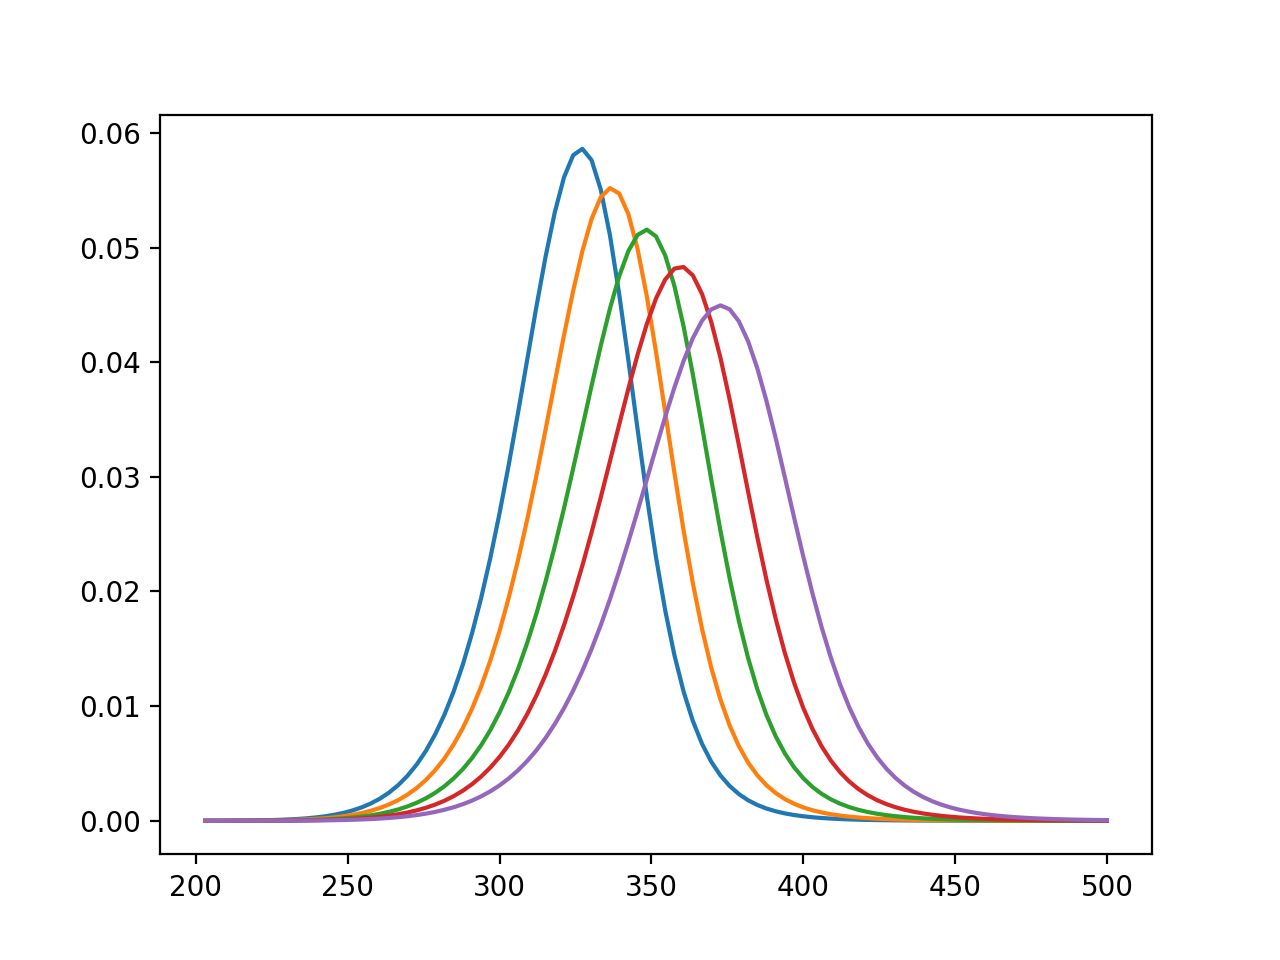

In [6]:
R = 8.3145 # J / mol-K

def concM(P, Ts, dH, dS):
    K = np.exp(-dH/(R*Ts) + dS/R)
    M = ( np.sqrt( 8 * P * K + 1 ) - 1 ) / (4*K)
    return M


dH = -1e5
dS = dH / (273. + 50.)
print(dH, dS)

Ts = np.linspace(200, 500, 100)

nth_deriv = 1

plt.figure()
for P in [1.0, 3.0, 10.0, 30.0, 100.0]:
    y = concM(P, Ts, dH, dS)
    plt.plot(Ts[nth_deriv:], np.diff(y, n=nth_deriv) / P)
plt.show()


In [3]:
# Column key:
#  4,5,6 --> N214A
#  7,8,9 --> Q256A
#  10,11,12 --> S284A
#  [10,11,12 --> wt]

df = pd.read_csv('max_derivative_plot_data.csv')[3:] # remove all A wells

# axes: (concentration, mutant, repeat)
x = np.array(df['transition_temperature']).reshape(7,3,3)
t = np.array(df['condition']).reshape(7,3,3)

# protein concentrations
Ps = np.array([ 100.0/(2**i) for i in range(7) ])
Ps_repeated = np.repeat(Ps, 3).reshape(7,3)

In [4]:
mutant_colors = ['b', 'r', 'green', 'purple']

plt.figure()

for m in range(3):
    for r in range(3):
        plt.scatter(Ps, x[:,m,r], color=mutant_colors[m])
    
plt.xlabel('Concentration ($\mu M$)')
plt.ylabel('Tm (C)')
plt.show()

<IPython.core.display.Javascript object>

In [5]:
mutant = 2

def diff(params):
    Tm = x[:,mutant,:]
    return dMdTzero(Ps_repeated, Tm + 273.0, params).flatten()

params_0 = (-1e4, 100.0)
res = least_squares(diff, params_0, bounds=( (-np.inf, 0.0), (0.0, np.inf) ))

print(res)

NameError: name 'dMdTzero' is not defined

In [ ]:
dH, dS = res['x']

mutant_colors = ['b', 'r', 'green', 'purple']

plt.figure()

plt.plot(Ps, T_star(Ps, dH, dS), color=mutant_colors[mutant])

for r in range(3):
    plt.scatter(Ps, x[:,m,r], color=mutant_colors[mutant])

    
plt.xlabel('Concentration ($\mu M$)')
plt.ylabel('Tm (C)')

plt.show()